In [1]:
using Pkg
using Metal

cd(@__DIR__)
Pkg.activate("../")
ParamFile = "../config/testparam.csv"  # maybe GeoPoints and planet1D should be fusioned

# batchGPU should be at this level (I have not made it as a module yet, since the choice of Metal/CUDA should be done in a manual way)
include("../src/batchFiles/batchGPU.jl")


include("../src/commonBatchs.jl")
#include("../src/flexOPT.jl")
include("../src/planet1D.jl")
include("../src/GeoPoints.jl")

  Activating 

devs = Metal.devices() = Metal.MTL.MTLDeviceInstance[Metal.MTL.MTLDeviceInstance (object of type AGXG13XDevice)]

project at `~/Documents/Github/flexOPT`



→ Using Metal backend (1 device(s))
Selected backend type: MetalBackend


Main.GeoPoints

In [2]:
using .commonBatchs, UnPack, Symbolics

In [3]:
include("../src/compactSymbolicFunctions/compactFunctionsArray.jl")
include("../src/compactSymbolicFunctions/BsplineHelpers.jl")
include("../src/CompactSymbolicFunctions/TaylorExpansionHelpers.jl")

plotTaylorExpansions (generic function with 1 method)

# input parameters

for B-spline

In [4]:
orderBspline1D = 2
YorderBspline1D = 3
#the coordinate in Δy is (as usual) with the offset 1
μᶜs = [1,1.5,2.5,3] # ∈ R for variable, the nodes for interpolated Taylor expansions
μs = [1,1.5,2.5,3] # ∈ R for field, the nodes for interpolated Taylor expansions
nodesFromOne = [1,2,3] # ∈ Z like [1,2,3], an array of integers collect(1:1:N) (nothing else!!)
ν = [2] # this should be one point (for the moment)

1-element Vector{Int64}:
 2

for Taylor expansion

In [5]:
lᶜ_nᶜ_max = 4 # variable
l_n_max = 4 # field


4

for ill-posed inversion of Taylor expansion coefficients

In [6]:
Δ = 1.0 # Float64


1.0

In [7]:

paramsforWYYKKIntegral = (orderBspline1D=orderBspline1D, YorderBspline1D=YorderBspline1D, μᶜs=μᶜs, μs=μs, nodesFromOne=nodesFromOne, ν=ν, Δ=Δ, l_n_max=l_n_max, lᶜ_nᶜ_max=lᶜ_nᶜ_max)

(orderBspline1D = 2, YorderBspline1D = 3, μᶜs = [1.0, 1.5, 2.5, 3.0], μs = [1.0, 1.5, 2.5, 3.0], nodesFromOne = [1, 2, 3], ν = [2], Δ = 1.0, l_n_max = 4, lᶜ_nᶜ_max = 4)

# starting 'WYYKKIntegral1D(paramsforWYYKKIntegral)'

In [8]:
# Δ should be strictly Float64

    # orders: -1 -> indicator function, 0 -> box car, >=1 -> B-spline

    # this computes the analytical value of the 1D integral between B-spline fns and weighted Taylor kernels
    # \int dx Bspline Y_μᶜ Y_μ  K_{lᶜ-nᶜ}(y-y_μᶜ) K_{l-n}(y-y_μ)

    # unlike the previous integralBsplineTaylorKernels1D, it computes for a specific ν
    # Cˡη;μ are computed for a specific geometry, so even though the boundary condition reduces
    # the number of available points, each Taylor expansion for K_{l-n}(y-y_μ) should be Ok

    @unpack orderBspline1D, YorderBspline1D, μᶜs, μs, nodesFromOne, ν, Δ, l_n_max, lᶜ_nᶜ_max = paramsforWYYKKIntegral


(orderBspline1D = 2, YorderBspline1D = 3, μᶜs = [1.0, 1.5, 2.5, 3.0], μs = [1.0, 1.5, 2.5, 3.0], nodesFromOne = [1, 2, 3], ν = [2], Δ = 1.0, l_n_max = 4, lᶜ_nᶜ_max = 4)

# preparation of B-splines (all these things should be inside the package)

In [9]:


allNodes = unique(sort(vcat(
    Float64.(nodesFromOne),
    Float64.(ν),
    Float64.(μs),
    Float64.(μᶜs),
)))

to_indices(xs, master) = searchsortedfirst.(Ref(master), Float64.(xs))

idx_nodesFromOne = to_indices(nodesFromOne, allNodes)
idx_ν            = to_indices(ν, allNodes)
idx_μs           = to_indices(μs, allNodes)
idx_μᶜs          = to_indices(μᶜs, allNodes)



4-element Vector{Int64}:
 1
 2
 4
 5

In [10]:
# for B-spline

paramsBSν  = (maximumOrder=orderBspline1D, allNodes = allNodes, idx_nodesNum = idx_nodesFromOne, idx_refPoints = idx_nodesFromOne, idx_selectedPoints = idx_ν)
paramsBSμᶜ = (maximumOrder=YorderBspline1D, allNodes = allNodes, idx_nodesNum = idx_nodesFromOne, idx_refPoints = idx_μs, idx_selectedPoints = idx_μᶜs)
paramsBSμ  = (maximumOrder=YorderBspline1D, allNodes = allNodes, idx_nodesNum = idx_nodesFromOne, idx_refPoints = idx_μs, idx_selectedPoints = idx_μs)
# idx_nodesNum : an ordinary consecutive integer increment from 1 (the numerical nodes with Δy)
# idx_refPoints_original : supporting nodes to construct the Bspline family
# idx_selectedPoints  : the node addresses that user needs to take, should be a subset of idx_refPoints_original


# for Taylor Expansions

paramsTEμᶜ = (maxL_MINUS_N=lᶜ_nᶜ_max, allNodes = allNodes, idx_nodesNum = idx_nodesFromOne, idx_selectedPoints = idx_μᶜs)
paramsTEμ  = (maxL_MINUS_N=l_n_max, allNodes = allNodes, idx_nodesNum = idx_nodesFromOne, idx_selectedPoints = idx_μs)




(maxL_MINUS_N = 4, allNodes = [1.0, 1.5, 2.0, 2.5, 3.0], idx_nodesNum = [1, 3, 5], idx_selectedPoints = [1, 2, 4, 5])

# computing $Y_\mu$, $Y_{\mu^\prime}$, $W_\nu$

In [11]:
Wν = constructBsplineFamily(paramsBSν);
Yμᶜ = constructBsplineFamily(paramsBSμᶜ);
Yμ = constructBsplineFamily(paramsBSμ);

In [12]:
Wν.b

CompactSymbolicFunctions{2, Array{Num, 4}}(5, 1, (3, 3), Num[x, Δx], Num[1.0, 1.5, 2.0, 2.5, 3.0], Num[0; 0; … ; 1; 0;;; 0; 0; … ; 0; 0;;; 0; 0; … ; 0; 0;;;; (x - Δx) / Δx; (x - Δx) / Δx; … ; (-x + 3.0Δx) / Δx; 0;;; 1 / Δx; 1 / Δx; … ; -1.0 / Δx; 0;;; 0; 0; … ; 0; 0;;;; (x^2 - 2x*Δx + Δx^2) / (2.0(Δx^2)); (x^2 - 2x*Δx + Δx^2) / (2.0(Δx^2)); … ; (-(x^2) + 6.0x*Δx - 8.0(Δx^2)) / (2.0(Δx^2)) + (-(x^2) + 4.0x*Δx - 3.0(Δx^2)) / (2.0(Δx^2)); 0;;; (2x - 2Δx) / (2.0(Δx^2)); (2x - 2Δx) / (2.0(Δx^2)); … ; (-8.0x + 20.0Δx) / (4.0(Δx^2)); 0;;; 2 / (2.0(Δx^2)); 2 / (2.0(Δx^2)); … ; -8.0 / (4.0(Δx^2)); 0])

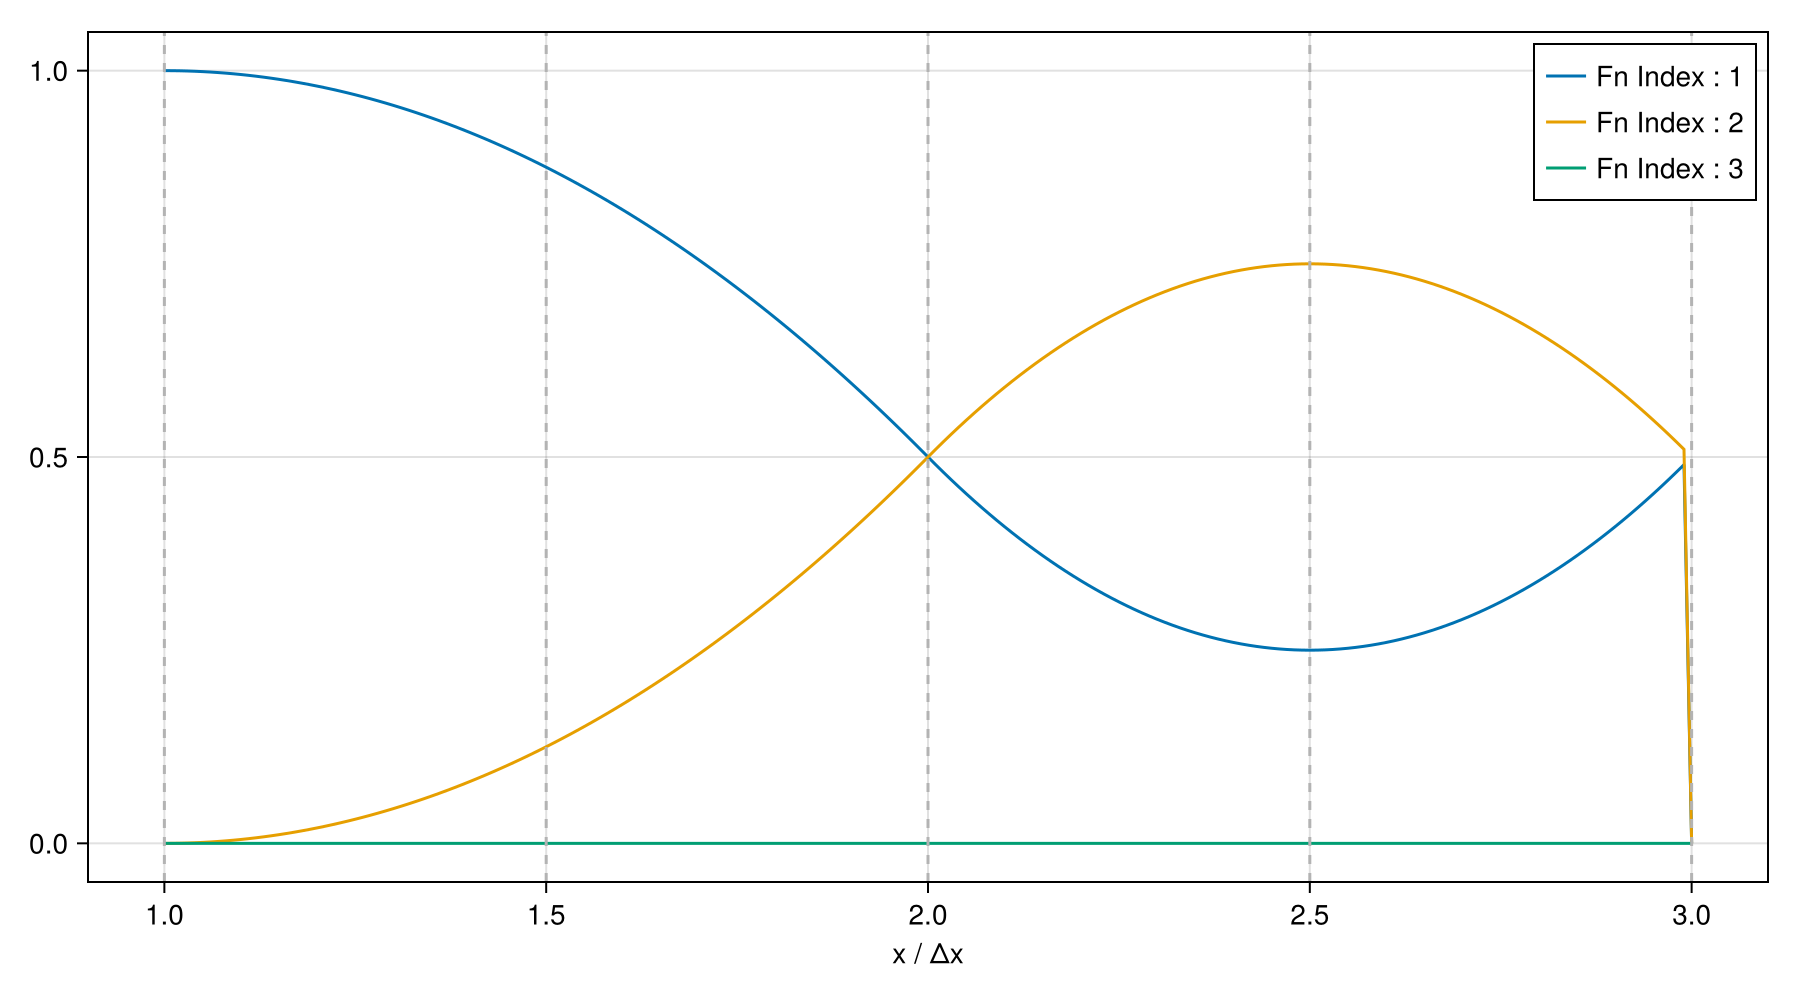

CairoMakie.Screen{IMAGE}


In [13]:

fig=plotBSpline(Wν.b_support; derivOrder=0,order=2, N=50)
display(fig)

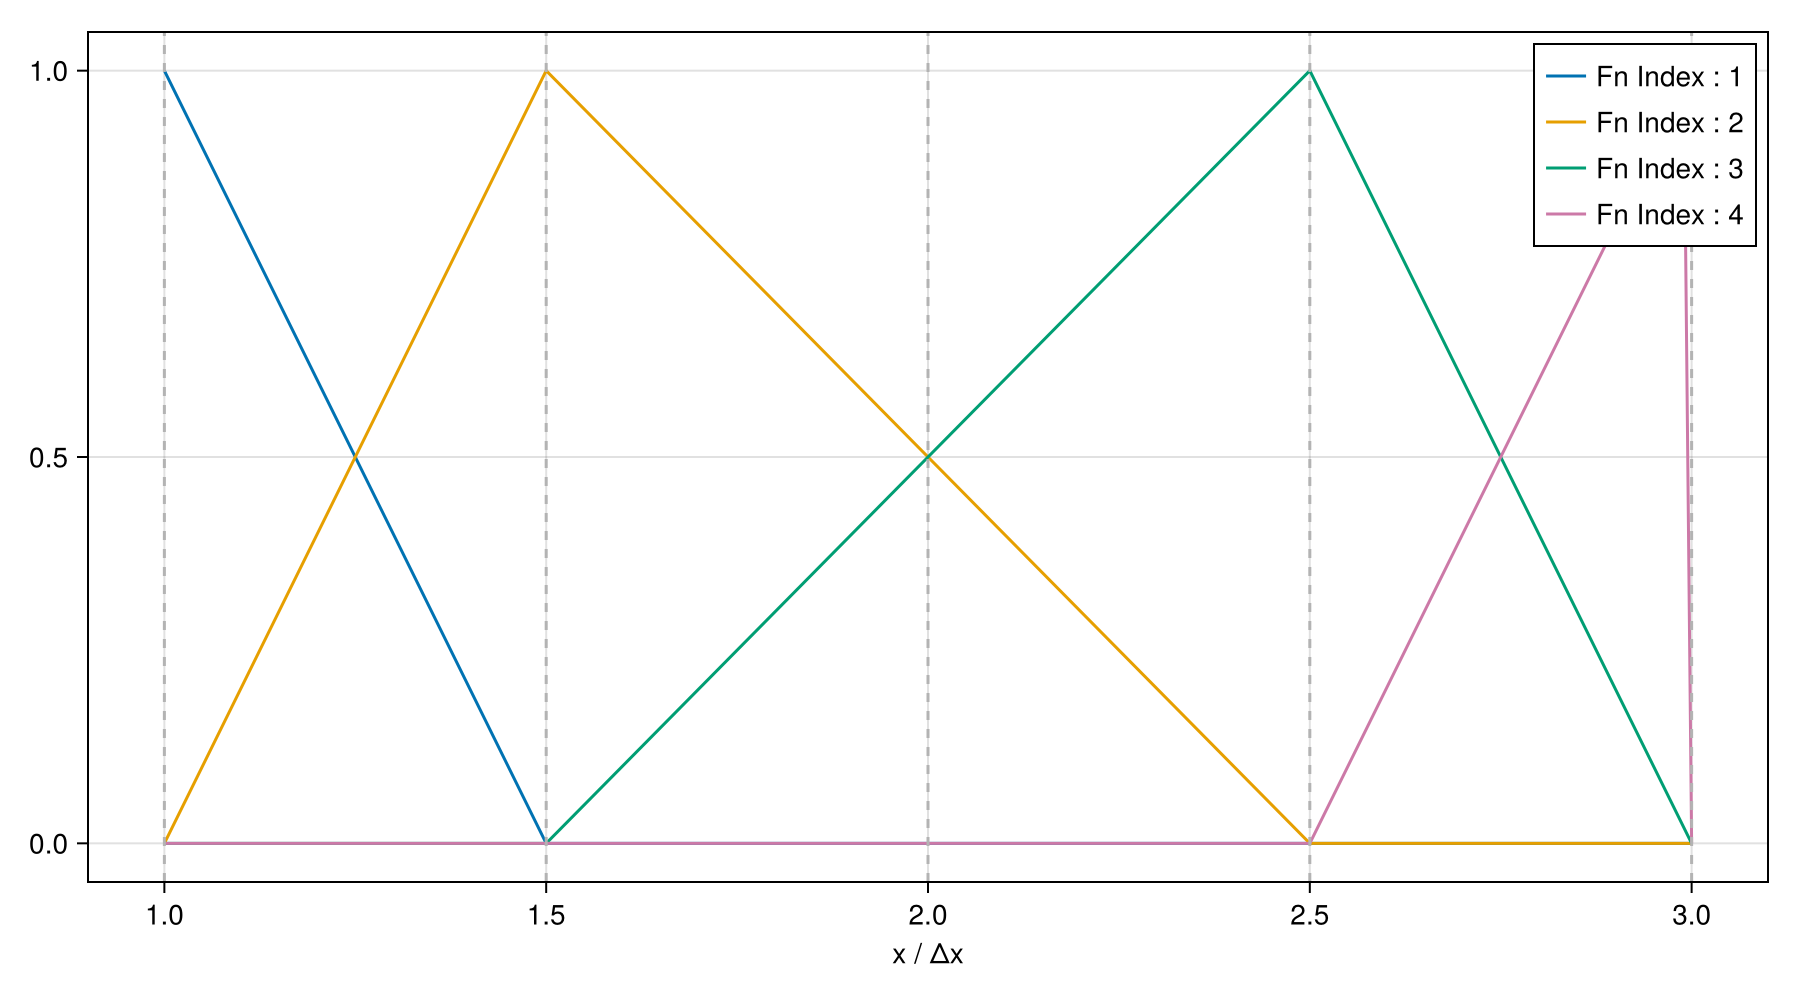

In [14]:
plotBSpline(Yμ.b; derivOrder=0, order=1, N=50)

# computing $K_\mu$, $K_{\mu^\prime}$

In [15]:
Kμᶜ=constructTaylorExpansions(paramsTEμᶜ) 
Kμ=constructTaylorExpansions(paramsTEμ) 

(k = CompactSymbolicFunctions{1, Array{Num, 3}}(5, 4, (5,), Num[x, Δx], Num[1.0, 1.5, 2.0, 2.5, 3.0], Num[1.0 1.0 1.0 1.0; 1.0 1.0 1.0 1.0; … ; 1.0 1.0 1.0 1.0; 1.0 1.0 1.0 1.0;;; x - Δx x - 1.5Δx x - 2.5Δx x - 3.0Δx; x - Δx x - 1.5Δx x - 2.5Δx x - 3.0Δx; … ; x - Δx x - 1.5Δx x - 2.5Δx x - 3.0Δx; x - Δx x - 1.5Δx x - 2.5Δx x - 3.0Δx;;; 0.5((x - Δx)^2) 0.5((x - 1.5Δx)^2) 0.5((x - 2.5Δx)^2) 0.5((x - 3.0Δx)^2); 0.5((x - Δx)^2) 0.5((x - 1.5Δx)^2) 0.5((x - 2.5Δx)^2) 0.5((x - 3.0Δx)^2); … ; 0.5((x - Δx)^2) 0.5((x - 1.5Δx)^2) 0.5((x - 2.5Δx)^2) 0.5((x - 3.0Δx)^2); 0.5((x - Δx)^2) 0.5((x - 1.5Δx)^2) 0.5((x - 2.5Δx)^2) 0.5((x - 3.0Δx)^2);;; 0.1666666666666666666666666666666666666666666666666666666666666666666666666666674((x - Δx)^3) 0.1666666666666666666666666666666666666666666666666666666666666666666666666666674((x - 1.5Δx)^3) 0.1666666666666666666666666666666666666666666666666666666666666666666666666666674((x - 2.5Δx)^3) 0.1666666666666666666666666666666666666666666666666666666666666666666666

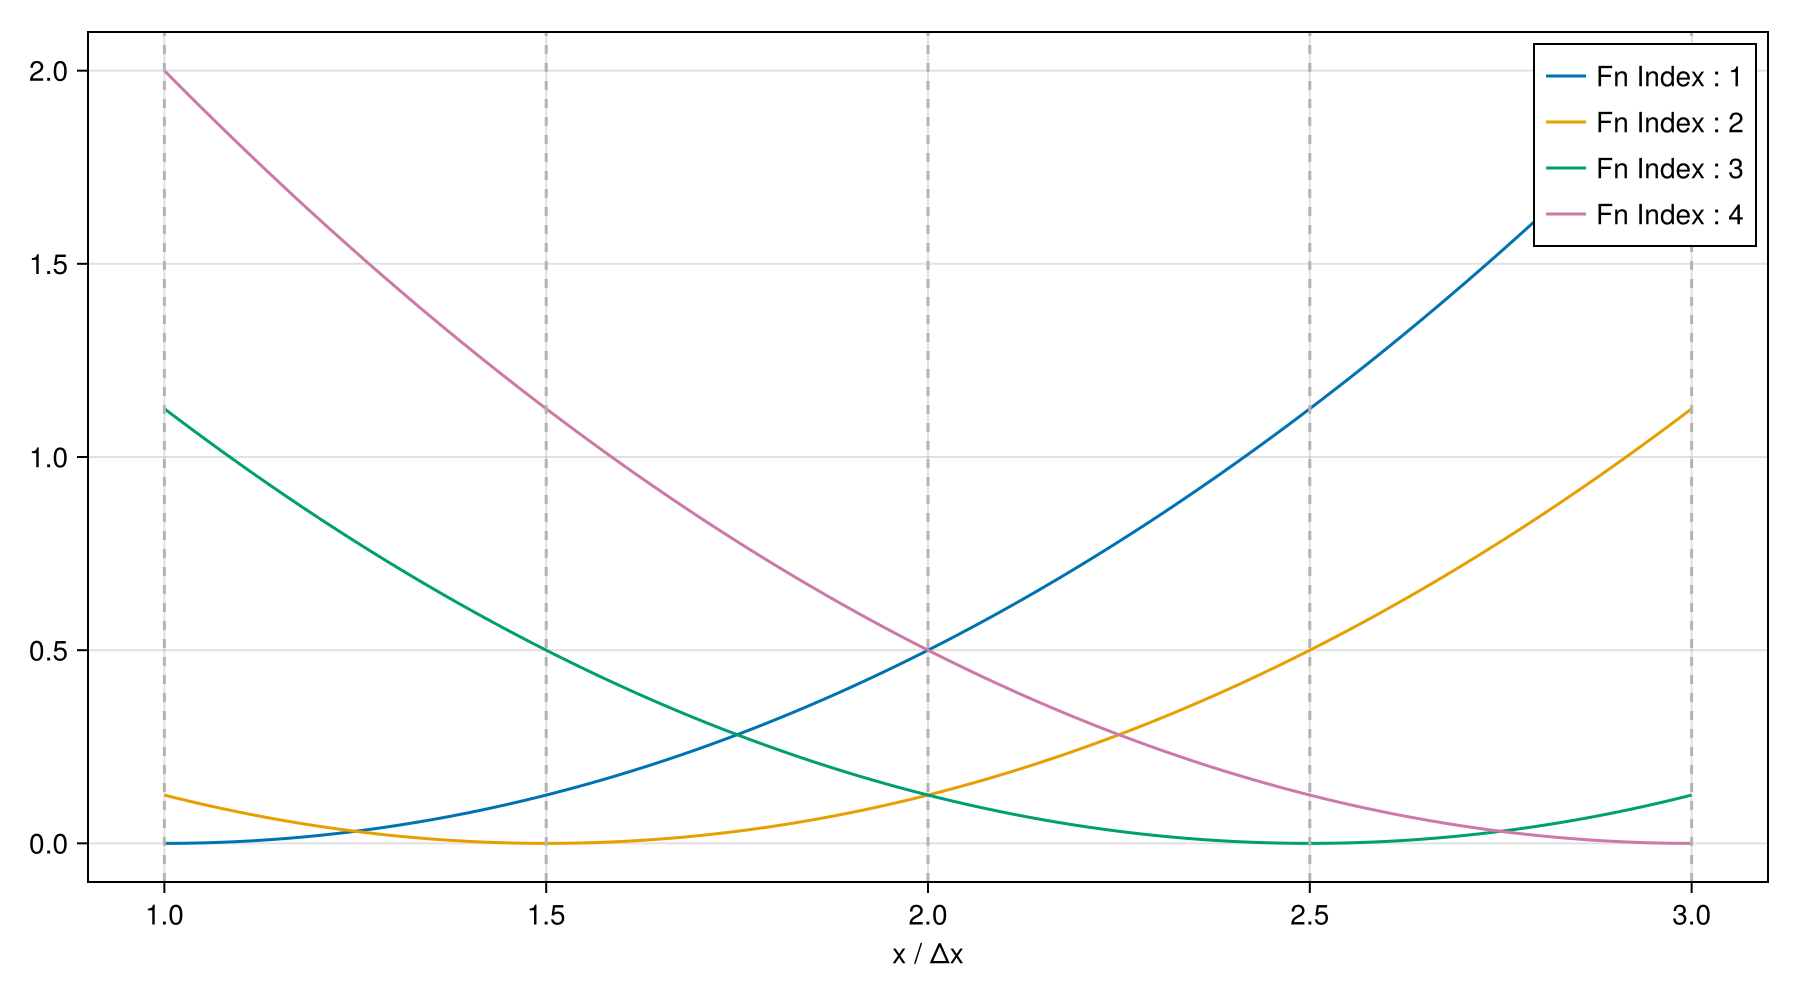

In [16]:
plotTaylorExpansions(Kμᶜ.k; l_n=2, N=50)

# constructing WYYKK functions

In [ ]:
WYYKK=CompactSymbolicFunctions(Yμ.b.nodes,1;auxDims=(l_n_max+1, lᶜ_nᶜ_max+1, length(μs),length(μᶜs),),variables=Yμ.b.variables)
YorderSlot = YorderBspline1D + 1 
orderSlot = orderBspline1D + 1
derivSlot = 1 # no derivatives
for iμᶜ ∈ eachindex(μᶜs), iμ ∈ eachindex(μs), lᶜ_nᶜ ∈ 0:lᶜ_nᶜ_max, l_n ∈ 0:l_n_max
    l_n_slot=l_n+1
    lᶜ_nᶜ_slot = lᶜ_nᶜ+1
    WYYKK.data[:,1,l_n_slot, lᶜ_nᶜ_slot, iμ, iμᶜ] = mySimplify(Wν.b.data[:,1,derivSlot,orderSlot].*Yμᶜ.b.data[:,iμᶜ,derivSlot,YorderSlot].*Yμ.b.data[:,iμ,derivSlot,YorderSlot].*Kμᶜ.k.data[:,iμᶜ,lᶜ_nᶜ_slot].*Kμ.k.data[:,iμ,l_n_slot])
end

In [ ]:
plotCompactSymbolicFunctions(WYYKK,(1,1,3,3,);N=50)

In [ ]:
WYYKK.data[:,1,1,1,2,2]

# making analytic integrals

In [ ]:
WYYKK_integral=lazyProduceOrLoad("WYYKK_integral_tmp",integrate,WYYKK,x)


In [ ]:
WYYKK_integral.data[:,1,1,1,2,2]

In [ ]:
continuousAntiDerivativesMaker!(WYYKK_integral) # this is only to 'visually' make beautiful the anti-derivatives
plotCompactSymbolicFunctions(WYYKK_integral,(1,1,2,2,);N=50)

# double check that the anti-derivatives are ok


In [ ]:
WYYKK_recovered=differentiate(WYYKK_integral,x)
plotCompactSymbolicFunctions(WYYKK_recovered,(1,1,2,2,);N=50)


In [ ]:
plotCompactSymbolicFunctions(WYYKK,(1,1,2,2,);N=50)

# now putting numerical Δx to have the WYYKK values 

In [ ]:
coefWYYKK = Array{Float64, 4}(undef,l_n_max+1,lᶜ_nᶜ_max+1,length(μs),length(μᶜs))

nodes = WYYKK_integral.nodes
numericalNodes = Δ .* nodes
numNodes = WYYKK_integral.numberNodes
x = WYYKK_integral.variables[1]
Δx = WYYKK_integral.variables[2]
for iμᶜ ∈ eachindex(μᶜs), iμ ∈ eachindex(μs), lᶜ_nᶜ ∈ 0:lᶜ_nᶜ_max, l_n ∈ 0:l_n_max
    l_n_slot=l_n+1
    lᶜ_nᶜ_slot = lᶜ_nᶜ+1
    tmpAntiDerivative=WYYKK_integral.data[:,1,l_n_slot, lᶜ_nᶜ_slot, iμ, iμᶜ]
    tmpCoef = 0.0
    for ι in 1:numNodes-1
        xLeft = numericalNodes[ι]
        xRight = numericalNodes[ι+1]
        expr = tmpAntiDerivative[ι]
        rightValue = Symbolics.value(Symbolics.substitute(expr, Dict(x => xRight, Δx => Δ)))
        leftValue = Symbolics.value(Symbolics.substitute(expr, Dict(x => xLeft, Δx => Δ)))
        tmpCoef += rightValue-leftValue
    end
    coefWYYKK[l_n_slot,lᶜ_nᶜ_slot,iμ,iμᶜ] = tmpCoef
end

In [ ]:
coefWYYKK

In [ ]:
tmpExpr = WYYKK.data[1,1,1,1,2,2]